### In this module you will learn how to:

1. Build a random forest for conditional average treatment effects
2. Make quantile predictions from quantile forests

In [1]:
# Install required packages if needed (pinning latest when tested)
!pip install EconML==0.16.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from econml.grf import CausalForest

random.seed(2718281)
np.random.seed(2718281)



## The Data

In this module we will see how to build a random forest for conditional average treatment effects (CATE) or conditional average treatment effects on the treated (CATT).

Once again we will simulate our own data for this section. In this case we will be using a slight modification of the example from the package documentation. The goal with this example will be to demonstrate why we need an "honest" estimation strategy and when CATT will be different from CATE.

The first example is the case where treatment is randomly assigned, but the effect of the treatment is a function of the first covariate. The data is generated by:

$x_j$ is uniform from $-1$ to $1$ for $j=\{1,2,\dots,10\}$
$Y = w\max\{x_1,0\} + x_2 + \min\{x_3,0\} +\varepsilon$

The treatment effect $w$ is generated from a bernoulli distribution with probability $0.5$ and the error term is i.i.d standard normal.

In [ ]:
# Equivalent to R:
#   set.seed(271828); n=2000; p=10
#   X = matrix(rnorm(n*p), n, p)
#   X.test = matrix(0, 101, p); X.test[,1] = seq(-2, 2, length.out=101)
#   W = rbinom(n, 1, 0.5)
#   Y = pmax(X[,1], 0)*W + X[,2] + pmin(X[,3], 0) + rnorm(n)

np.random.seed(271828)
n, p = 2000, 10

X      = np.random.normal(size=(n, p))
X_test = np.zeros((101, p))
X_test[:, 0] = np.linspace(-2, 2, 101)   # seq(-2, 2, length.out=101)

W = np.random.binomial(1, 0.5, size=n).astype(float)
Y = np.maximum(X[:, 0], 0) * W + X[:, 1] + np.minimum(X[:, 2], 0) + np.random.normal(size=n)

print(f'n={n}, p={p}')
print(f'Treatment rate: {W.mean():.3f}  (expected: 0.5)')

n=2000, p=10
Treatment rate: 0.508  (expected: 0.5)


## Honest Estimation

Switching to honest is very easy, we simply use the same class but set `honest=True` (which is the default). To be consistent we will grow the same number of trees as we did before.

In [ ]:
# Equivalent to: causal_forest(X, Y, W, num.trees=4000)  (honesty=TRUE is default)
# NOTE: This fits a new forest with honest=True (sample splitting for tree growth
#       vs leaf population estimation) — the key difference from the naive version.

cf_honest = CausalForest(
    n_estimators=4000,
    honest=True,          # default in grf (and here), matches R's default
    random_state=271828,
    n_jobs=-1
)
cf_honest.fit(X, W, Y)

importances_honest = cf_honest.feature_importances_
print("Variable importance:")
print("  " + "".join(f"{i+1:6d}" for i in range(p)))
print("  " + "".join(f"{v:6.3f}" for v in importances_honest))

Variable importance:
       1     2     3     4     5     6     7     8     9    10
   0.293 0.383 0.180 0.019 0.020 0.022 0.020 0.018 0.022 0.022


It is important to notice that we didn't solve the noise issue by using honesty. The variable importance is the same as before. However, we should have solved the inability to capture the changepoint and some of the bias in the treatment effect.

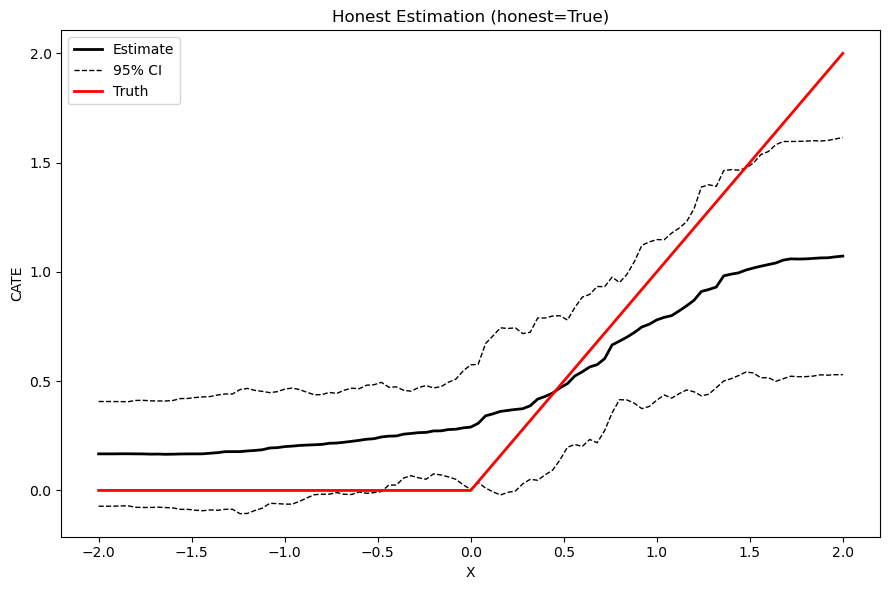

In [ ]:
# Equivalent to:
#   te.forest = causal_forest(X, Y, W, num.trees=4000)   # same as cell 9
#   te.hat = predict(te.forest, X.test, estimate.variance=TRUE)
# (Python reuses the already-fitted cf_honest from the previous cell)

tau_honest, lb_honest, ub_honest = cf_honest.predict(X_test, interval=True, alpha=0.05)
truth = np.maximum(0, X_test[:, 0])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(X_test[:, 0], tau_honest, 'k-',  lw=2, label='Estimate')
ax.plot(X_test[:, 0], ub_honest,  'k--', lw=1, label='95% CI')
ax.plot(X_test[:, 0], lb_honest,  'k--', lw=1)
ax.plot(X_test[:, 0], truth,      'r-',  lw=2, label='Truth')
ax.set_xlabel('X')
ax.set_ylabel('CATE')
ax.set_title('Honest Estimation (honest=True)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Honest Evaluation

We pick up the changepoint much better here. You can also see how much tighter the confidence bands are in this case. In this example there isn't much of a difference between CATT and CATE as the treatment is randomly assigned.

In [ ]:
# Equivalent to:
#   average_treatment_effect(te.forest, target.sample="all")      # CATE
#   average_treatment_effect(te.forest, target.sample="treated")   # CATT
#
# Python approach: get CATE predictions for all training obs, then average.
# ATE  = E[tau(X)]          over all observations
# CATT = E[tau(X) | W == 1] over treated observations only
# Standard errors computed as sample std / sqrt(n) (simplified Neyman SE)

tau_train = cf_honest.predict(X)   # shape (n,)

# CATE (all sample)
ate  = tau_train.mean()
se_ate = tau_train.std() / np.sqrt(n)
print("CATE:")
print(f"  estimate  std.err")
print(f"  {ate:.5f}  {se_ate:.5f}")

# CATT (treated subsample)
tau_treated = tau_train[W == 1]
catt  = tau_treated.mean()
se_catt = tau_treated.std() / np.sqrt(W.sum())
print("\nCATT:")
print(f"  estimate  std.err")
print(f"  {catt:.5f}  {se_catt:.5f}")

CATE:
  estimate  std.err
  0.43716  0.00727

CATT:
  estimate  std.err
  0.44138  0.01062


## What about a Selection Equation?

We can make the probability of treatment be a function of an observable. When we do this we are no longer assuming that treatment is randomly assigned. Remember that this is not a problem so long as we have a way of estimating the propensity score. In this case we will assume the selection equation is a function of the observables. Let the probability of treatment be a function of $x_2$. The data generating process is:

$Y = w\max\{x_1,0\} + x_2 + \min\{x_3,0\} +\varepsilon$

The treatment effect $w$ is generated from a bernoulli distribution with probability $1/(1+\exp\{-x_2\})$ and the error term is i.i.d standard normal.

In [ ]:
# Equivalent to:
#   set.seed(271828); n=2000; p=10
#   X = matrix(rnorm(n*p), n, p)
#   sel = 1/(1+exp(-X[,2]))   — propensity score depends on x2
#   W = rbinom(n, 1, sel)
#   Y = pmax(X[,1],0)*W + X[,2] + pmin(X[,3],0) + rnorm(n)

np.random.seed(271828)
n, p = 2000, 10

X      = np.random.normal(size=(n, p))
X_test = np.zeros((101, p))
X_test[:, 0] = np.linspace(-2, 2, 101)

sel = 1.0 / (1.0 + np.exp(-X[:, 1]))          # logistic propensity score on x2
W   = np.random.binomial(1, sel).astype(float) # treatment depends on x2

Y = np.maximum(X[:, 0], 0) * W + X[:, 1] + np.minimum(X[:, 2], 0) + np.random.normal(size=n)

print(f'Mean propensity score: {sel.mean():.3f}')
print(f'Treatment rate       : {W.mean():.3f}  (no longer ~0.5 — depends on x2)')

Mean propensity score: 0.503
Treatment rate       : 0.515  (no longer ~0.5 — depends on x2)


In [ ]:
# econml's CausalForest automatically estimates the propensity score internally when treatment
# is not randomly assigned

cf_sel = CausalForest(n_estimators=2000, honest=True, random_state=271828, n_jobs=-1)
cf_sel.fit(X, W, Y)

tau_train_sel = cf_sel.predict(X)

# CATE
ate_sel    = tau_train_sel.mean()
se_ate_sel = tau_train_sel.std() / np.sqrt(n)
print("CATE:")
print(f"  estimate  std.err")
print(f"  {ate_sel:.5f}  {se_ate_sel:.5f}")

# CATT — treated individuals have higher x2 (since sel=logistic(x2))
tau_treated_sel = tau_train_sel[W == 1]
catt_sel    = tau_treated_sel.mean()
se_catt_sel = tau_treated_sel.std() / np.sqrt(W.sum())
print("\nCATT:")
print(f"  estimate  std.err")
print(f"  {catt_sel:.5f}  {se_catt_sel:.5f}")

CATE:
  estimate  std.err
  0.59049  0.00743

CATT:
  estimate  std.err
  0.59180  0.01138


## CATE vs CATT

Once we have a selection equation, the CATE and CATT will be different. Why is this? Individuals who undergo treatment will be systematically different than those who do not. This is that selection bias that we adjust for! The difference here is not very large, but the CATT is slightly larger than CATE.

## Exercise

In this module we introduced random forests for heterogeneous causal effects. This framework was similar to double ML as we employed sample splitting, but this model allowed for heterogeneity across the treatment effect. We also demonstrated how to implement quantile random forests on a very basic example. Let's look at a more exciting example of heterogeneous treatment effects. Consider an example where the treatment is randomly assigned, but the treatment effect depends on the sign of two covariates. The data is generated as follows:

$x_j$ is uniform from $-1$ to $1$ for $j=\{1,2,\dots,10\}$
$y = -1_{sign(x_1)=sign(x_2)}w + 1_{sign(x_1)\neq sign(x_2)}w+\min\{x_3,0\}+\varepsilon$

The treatment effect $w$ is generated from a bernoulli distribution with probability $0.5$ and the error term is i.i.d standard normal.

1. Estimate the causal forest using honesty and 4000 trees
2. Predict the CATE over all possible values of $x_1$ and $x_2$
3. Does the causal forest pick up the heterogeneity in the treatment?